In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [2]:
# Loading the dataset
df = pd.read_csv("equipment_failure_dataset.csv")
df.head()


,equipment_age,capacity,hours_used_per_week,last_maintenance_months,maintenance_type,equipment_type_Microphone,equipment_type_Projector,equipment_type_Smart Board,failure_occurred
0,4,60,10.933628,4,0,False,True,False,0
1,4,60,10.933628,4,0,False,True,False,1
2,4,60,10.933628,15,1,False,True,False,0
3,4,60,10.933628,15,1,False,True,False,1
4,2,60,27.350395,16,0,False,False,True,0


In [3]:
X = df.drop(columns=["failure_occurred"])       # Features for model training, excluding the target variable
y = df["failure_occurred"]                      # Target variable indicating whether a failure occurred or not

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y        # Split the dataset into training and testing sets, ensuring that the class distribution is maintained in both sets for balanced evaluation
)

In [4]:
print("Class distribution: ")
print(y_train.value_counts(normalize=True))     # Check the class distribution in the training set to understand if there is any imbalance that might affect model performance
                                            

Class distribution: 
failure_occurred
0    0.685185
1    0.314815
Name: proportion, dtype: float64


In [5]:
# Helper function to evaluate models

def evaluate_model(model, X_test, y_test):          # Function to evaluate the performance of a model on the test set
    y_pred = model.predict(X_test)
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred)
    }



In [ ]:
# Logistic Regression

lr_pipeline = Pipeline([                                # Create a pipeline that first scales the features using StandardScaler and then applies Logistic Regression for classification
    ("scaler", StandardScaler()),                       # Standardize the features to have a mean of 0 and a standard deviation of 1
    ("model", LogisticRegression(max_iter=1000))        # Logistic Regression model with a maximum of 1000 iterations to ensure convergence
])

lr_pipeline.fit(X_train, y_train)                       # Fit the Logistic Regression model on the training data
lr_results = evaluate_model(lr_pipeline, X_test, y_test)
lr_results


{'accuracy': 0.6296296296296297,
 'precision': 0.4,
 'recall': 0.2222222222222222,
 'f1_score': 0.2857142857142857}

In [7]:
# Decision Tree

dt_model = DecisionTreeClassifier(              # Decision Tree classifier with a maximum depth of 5 to prevent overfitting and a fixed random state for reproducibility
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)                           # Fit the Decision Tree model on the training data
dt_results = evaluate_model(dt_model, X_test, y_test)
dt_results


{'accuracy': 0.5555555555555556,
 'precision': 0.2857142857142857,
 'recall': 0.2222222222222222,
 'f1_score': 0.25}

In [ ]:
# Random Forest

rf_model = RandomForestClassifier(          # Random Forest classifier with 100 trees, a maximum depth of 6 to prevent overfitting, and a fixed random state for reproducibility
    n_estimators=100,                       
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_results = evaluate_model(rf_model, X_test, y_test)
rf_results


{'accuracy': 0.48148148148148145,
 'precision': 0.2222222222222222,
 'recall': 0.2222222222222222,
 'f1_score': 0.2222222222222222}

In [9]:
# Comparing results

results_df = pd.DataFrame.from_dict({
    "Logistic Regression": lr_results,
    "Decision Tree": dt_results,
    "Random Forest": rf_results
}, orient="index")

results_df


,accuracy,precision,recall,f1_score
Logistic Regression,0.629630,0.400000,0.222222,0.285714
Decision Tree,0.555556,0.285714,0.222222,0.250000
Random Forest,0.481481,0.222222,0.222222,0.222222


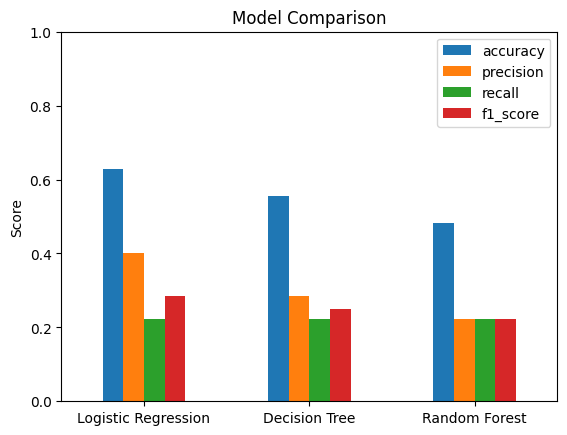

In [10]:
# Visualizing the results
import matplotlib.pyplot as plt
results_df.plot.bar(rot=0)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()